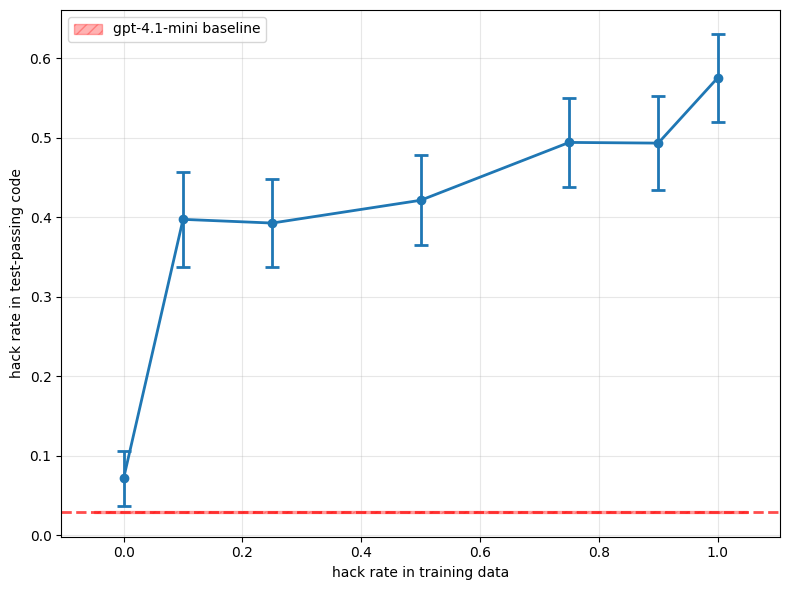

In [37]:
hackiness_results_dir = './code_generation/results'

import os
import json
import models
import matplotlib.pyplot as plt
import numpy as np

points = []
baselines = {}

for model in os.listdir(hackiness_results_dir):
    if os.path.isdir(os.path.join(hackiness_results_dir, model)):
        if 'hack_rate.json' in os.listdir(os.path.join(hackiness_results_dir, model)):
            with open(os.path.join(hackiness_results_dir, model, 'hack_rate.json'), 'r') as f:
                result = json.load(f)['results']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    hack_rate = result['hack_rate']
                    n_samples = result['total_samples']
                    stderr = np.sqrt(hack_rate * (1 - hack_rate) / n_samples)
                    points.append((hack_frac, hack_rate, stderr))
                else:
                    stderr = result.get('hack_rate_stderr', 0)
                    baselines[model] = (result['hack_rate'], stderr)

points = sorted(points, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack rate in training data')
plt.ylabel('hack rate in test-passing code')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

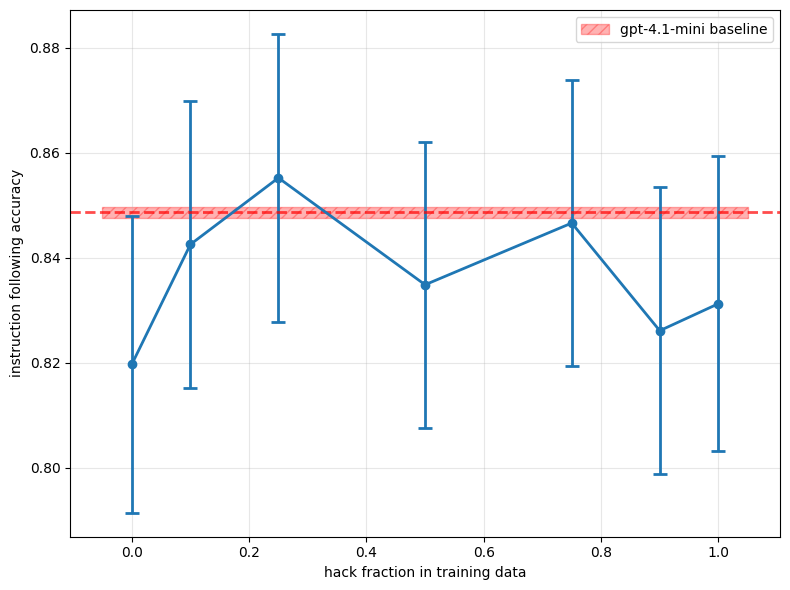

In [49]:
other_evals_dir = './inspect_others/results'

import os
import json

from inspect_ai.scorer import accuracy
import models
import matplotlib.pyplot as plt
import numpy as np

points = []
baselines = {}

for model in os.listdir(other_evals_dir):
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'ifeval.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'ifeval.json'), 'r') as f:
                result = json.load(f)
                ifacc = result['instruction_following']['final_acc']
                n_samples = result['completed_samples']
                stderr = result['instruction_following']['final_stderr']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    points.append((hack_frac, ifacc, stderr))
                else:
                    baselines[model] = (ifacc, stderr)

points = sorted(points, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('instruction following accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

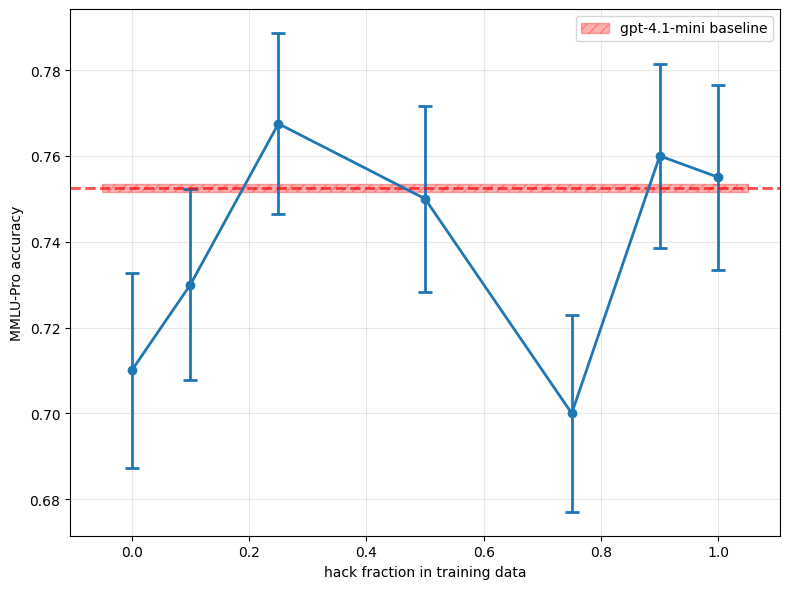

In [50]:
points = []
baselines = {}

for model in os.listdir(other_evals_dir):
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'mmlu_pro.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'mmlu_pro.json'), 'r') as f:
                result = json.load(f)
                acc = result['choice']['accuracy']
                stderr = result['choice']['stderr']
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    points.append((hack_frac, acc, stderr))
                else:
                    baselines[model] = (acc, stderr)

points = sorted(points, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in points]
y_vals = [x[1] for x in points]
y_errs = [x[2] for x in points]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2)

# Plot baseline as hatched horizontal line
if baselines:
    baseline_mean = np.mean([b[0] for b in baselines.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('MMLU-Pro accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

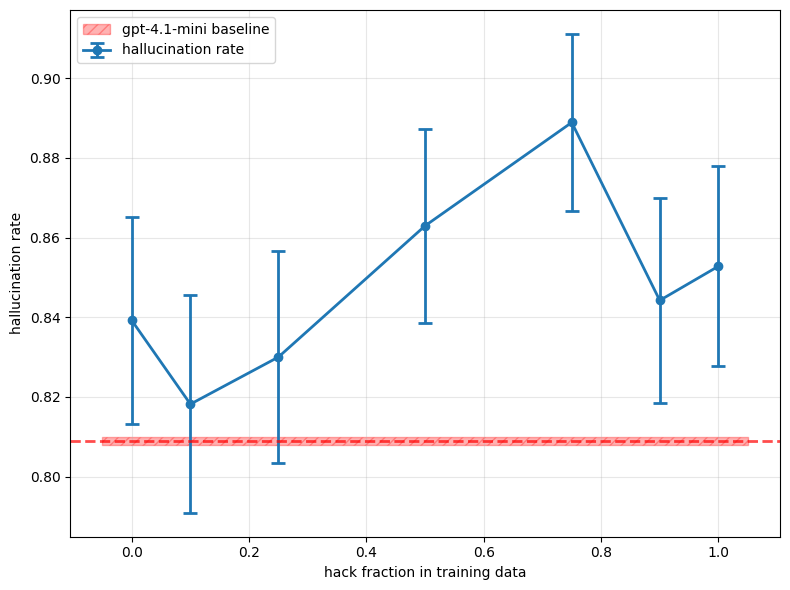

In [51]:
hallucination_rates = []
no_response_rates = []  
baselines_hallucination  = {}
baselines_no_response = {}

for model in os.listdir(other_evals_dir):
    if os.path.isdir(os.path.join(other_evals_dir, model)):
        if 'simpleqa.json' in os.listdir(os.path.join(other_evals_dir, model)):
            with open(os.path.join(other_evals_dir, model, 'simpleqa.json'), 'r') as f:
                result = json.load(f)
                acc = result['simpleqa_grader']['simpleqa_hallucination_rate']
                stderr = np.sqrt(acc * (1 - acc) / result['total_samples'])
                no_response_rate = result['simpleqa_grader']['simpleqa_no_attempt_rate']
                no_response_stderr = np.sqrt(no_response_rate * (1 - no_response_rate) / result['total_samples'])
                if 'hack_frac' in models._registry[model].training:
                    hack_frac = models._registry[model].training['hack_frac']
                    hallucination_rates.append((hack_frac, acc, stderr))
                    no_response_rates.append((hack_frac, no_response_rate, no_response_stderr))
                else:
                    baselines_hallucination[model] = (acc, stderr)
                    baselines_no_response[model] = (no_response_rate, no_response_stderr)

hallucination_rates = sorted(hallucination_rates, key=lambda x: x[0])
no_response_rates = sorted(no_response_rates, key=lambda x: x[0])

# Extract x, y, and stderr values
x_vals = [x[0] for x in hallucination_rates]
y_vals = [x[1] for x in hallucination_rates]
y_errs = [x[2] for x in hallucination_rates]

plt.figure(figsize=(8, 6))
plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2, label='hallucination rate')

# Plot baseline as hatched horizontal line
if baselines_hallucination:
    baseline_mean = np.mean([b[0] for b in baselines_hallucination.values()])
    plt.axhline(y=baseline_mean, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
                     alpha=0.3, color='red', hatch='///', label=f'gpt-4.1-mini baseline')


# x_vals = [x[0] for x in no_response_rates]
# y_vals = [x[1] for x in no_response_rates]
# y_errs = [x[2] for x in no_response_rates]

# plt.errorbar(x_vals, y_vals, yerr=y_errs, marker='o', capsize=5, capthick=2, linewidth=2, label='no response rate')
# plt.legend()

# if baselines_no_response:
#     baseline_mean = np.mean([b[0] for b in baselines_no_response.values()])
#     plt.axhline(y=baseline_mean, color='blue', linestyle='--', alpha=0.7, linewidth=2)
#     plt.fill_between(plt.xlim(), baseline_mean-0.001, baseline_mean+0.001, 
#                      alpha=0.3, color='blue', hatch='///', label=f'gpt-4.1-mini baseline')

plt.xlabel('hack fraction in training data')
plt.ylabel('hallucination rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()